#2021245151 정용의

# **Import Modules Section**

In [18]:
!pip3 install pandas matplotlib scikit-learn tensorflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re  # 텍스트 전처리를 위한 정규 표현식 패키지
from sklearn.model_selection import train_test_split  # 데이터셋 분할
from sklearn.preprocessing import LabelEncoder  # 감정 레이블을 숫자로 인코딩
from tensorflow.keras.preprocessing.text import Tokenizer  # 텍스트 데이터를 정수로 변환하는 토크나이저
from tensorflow.keras.preprocessing.sequence import pad_sequences  # 시퀀스 길이를 맞추기 위한 패딩 함수
from tensorflow.keras.models import Sequential  # 순차 모델 선언
from tensorflow.keras.layers import Dense, Embedding, Conv1D, GlobalMaxPooling1D, Dropout, BatchNormalization  # 모델의 각 계층을 구성하는 레이어
from tensorflow.keras.optimizers import Adam  # 최적화 알고리즘
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau  # 학습을 조기 종료하거나 학습률을 감소시키는 콜백
from google.colab import drive  # Google Colab에서 드라이브 연결
from tensorflow.keras.regularizers import l2  # L2 정규화를 적용하기 위한 패키지


# **Load and Preprocess Dataset Section**

In [19]:
# 드라이브 마운트 (Google Colab에서 구글 드라이브를 연결)
drive.mount('/content/drive')

# 데이터 로드 및 전처리
file_path = '/content/drive/MyDrive/실습/IMDB.csv'  # IMDB 데이터 파일 경로 설정
df = pd.read_csv(file_path)  # CSV 파일을 DataFrame으로 불러옴

# 텍스트 전처리 함수 정의
def text_cleaning(text):
    text = re.sub(r'<[^>]+>', '', text)  # HTML 태그 제거
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # 알파벳 이외의 문자 제거
    text = text.lower()  # 소문자로 변환
    return text

df['review'] = df['review'].apply(text_cleaning)  # 리뷰 데이터를 전처리

# 레이블 인코딩 (긍정/부정을 숫자로 변환)
label_encoder = LabelEncoder()
df['sentiment'] = label_encoder.fit_transform(df['sentiment'])  # 긍정, 부정 감정을 0과 1로 인코딩


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


리뷰 텍스트에서 HTML 태그를 제거하고 알파벳 이외의 문자를 모두 제거한 다음 소문자로 변환하여 텍스트 데이터를 모델이 처리할 수 있도록 정형화하는 작업을 수행한다. 판다스의 apply함수를 사용해서 데이터프레임의 각 리뷰 텍스트에 text_cleaning함수를 적용하고 LabelEncoder로 IMDB 데이터셋에 있는 Positive와 Negative 감정 레이블을 숫자 0, 1로 변환하는 과정을 수행 (모델이 숫자 레이블을 기반으로 감정 분류를 수행할 수 있도록 하는과정)

# **Data Split and Tokenization Section**

In [20]:
# 학습 및 테스트 데이터셋 분리 (80% 학습, 20% 테스트)
train_text, test_text, train_label, test_label = train_test_split(df['review'], df['sentiment'], test_size=0.2, random_state=42)

# 토크나이저를 사용하여 텍스트 데이터를 정수 인덱스로 변환
max_features = 10000  # 단어 집합 크기 설정
tokenizer = Tokenizer(num_words=max_features)  # 토크나이저 초기화
tokenizer.fit_on_texts(train_text)  # 학습 데이터로 토크나이저 훈련

# 텍스트 데이터를 정수 인덱스 시퀀스로 변환
x_train = tokenizer.texts_to_sequences(train_text)
x_test = tokenizer.texts_to_sequences(test_text)

# 시퀀스 길이를 맞추기 위한 패딩
max_len = 500  # 각 리뷰의 최대 길이 설정
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)


텍스트 데이터를 Train과 Test 데이터로 나눈 후, 모델 학습에 적합한 형태로 변환하는 과정 수행 먼저 Train_test_split함수를 사용해서 전체 데이터중 80%는 Train data 그리고 20%의 Test data로 나누고 랜덤 시드로 고정해서 데이터를 마죽위로 섞지만 결과는 동일하게 나오도록 설정하고 토크나이저로 텍스트 데이터를 숫자로 변환하는데 텍스트 자체를 직접 처리할 수 없으니까 각 단어를 고유 숫자 인덱스로 변환시키는 과정을 거친 후에 변환된 단어 인덱스들의 길이가 제 각 각일 수 있으니까 pad_sequences함수로 모든 텍스트의 길이를 동일하게 맞춰준다. 리뷰가 500단어 이하라면 0으로 채워 길이를 맞추고, 500단어를 초과하면 앞부분을 자르고 이런식으로 변환된 데이터를 신경망 모델이 처리할 수 있는 형태로 가공

# **Model Definition and Compilation Section**

In [21]:
# CNN 모델 정의
model = Sequential()

# 단어 임베딩 계층: 각 단어를 벡터로 변환
embedding_dims = 256  # 임베딩 벡터의 차원 설정
model.add(Embedding(max_features, embedding_dims, input_length=max_len))
model.add(Dropout(0.5))  # 과적합 방지를 위한 드롭아웃 적용

# 1D 합성곱 계층: 텍스트 데이터에서 특징을 추출
model.add(Conv1D(256, 5, padding='valid', activation='relu', strides=1, kernel_regularizer=l2(0.001)))  # L2 정규화 추가
model.add(BatchNormalization())  # 배치 정규화를 통해 학습 안정성 확보

# GlobalMaxPooling1D 계층: 가장 중요한 정보를 추출하여 차원 축소
model.add(GlobalMaxPooling1D())

# 완전 연결층
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))  # L2 정규화 적용
model.add(Dropout(0.5))  # 드롭아웃 적용

# 출력층: 이진 분류를 위해 시그모이드 활성화 함수 사용
model.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


단어 임베딩 계층에서 입력된 단어를 256차원의 백터로 변환한다. 드롭아웃은 0.5를 적용해 과적합을 방지하도록하고 1D 합성곱 계층에서 256개의 필터를 사용해 텍스트에서 특징을 추출하고, L2 정규화와 배치정규화를 적용해 학습이 안정적으로 수행될 수 있도록 한다. 이후 GlobalMaxPolling1D를 사용해 중요 정보를 추출해 차원을 축소하고 완전 연결계층에서는 128개의 유닛과 relu활성화를 사용하고, 다시 드롭아웃과 L2정규화로 과적합을 방지하고 마지막으로 출력중에 sigmoid를 사용해 긍정/부정 분류를 수행.

# **Model Training and Evaluation Section**

Model Training and Evaluation Section. 모델 학습과 평가를 담당하는 라인이다. 먼저 모델 컴파일에서 Adam Optimzier를 사용해 학습 속도를 조정하고, 손실함수로는 이진분류에 적합한 Binary_crossentropy를 사용한다. Learning_rate은 0.00005로 조금 낮을 수 있긴하지만 보다 신중한 학습을 유도하기 위해 낮게 설정. 다음으로 콜백함수를 정의해서 학습이 불필요하게 길어지지 않도록 작성. EarlyStopping 즉 검증 손실이 더 이상 개선되지 않으면 학습을 중단하고, ReduceLRonPlateau는 검증 손실이 개선되지 않으면 학습률을 감소시킨다. 그리고 추가적으로 각 에포크의 결과를 hisory_dict에 저장해서 이후 결과를 출력하도록 하였고 검증 정확도가 90%를 넘으면 조기 종료하도록 설정.

In [22]:
# 모델 컴파일 (Adam 옵티마이저 및 binary_crossentropy 손실 함수 사용)
learning_rate = 0.00005  # 매우 낮은 초기 학습률 설정
epochs = 30  # 총 에포크 수 정의
batch_size = 32  # 배치 크기 정의

model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=learning_rate), metrics=['accuracy'])

# 콜백 설정 (EarlyStopping과 ReduceLROnPlateau 사용)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=0.00001)

# 모델 학습 및 에포크 별 결과 출력
history_dict = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

for epoch in range(epochs):
    # 매 에포크마다 학습 및 평가 진행
    history = model.fit(x_train, train_label, batch_size=batch_size, epochs=1, validation_data=(x_test, test_label), verbose=0)

    # 에포크 결과 저장
    train_loss = history.history['loss'][0]
    val_loss = history.history['val_loss'][0]
    val_acc = history.history['val_accuracy'][0] * 100

    # 에포크 결과를 history_dict에 저장
    history_dict['loss'].append(train_loss)
    history_dict['val_loss'].append(val_loss)
    history_dict['accuracy'].append(history.history['accuracy'][0])
    history_dict['val_accuracy'].append(history.history['val_accuracy'][0])

    # 에포크 결과 출력
    print(f'Epoch {epoch+1}, Train Loss: {train_loss:.3f}, Validation Loss: {val_loss:.3f}, Validation Accuracy: {val_acc:.2f}%')

    # 학습이 조기 종료 조건을 만족하면 종료
    if val_acc >= 90:
        print(f'Validation accuracy reached 90% at epoch {epoch+1}. Stopping training.')
        break


Epoch 1, Train Loss: 1.157, Validation Loss: 1.037, Validation Accuracy: 64.43%
Epoch 2, Train Loss: 0.970, Validation Loss: 0.865, Validation Accuracy: 75.82%
Epoch 3, Train Loss: 0.841, Validation Loss: 0.761, Validation Accuracy: 80.10%
Epoch 4, Train Loss: 0.747, Validation Loss: 0.674, Validation Accuracy: 84.25%
Epoch 5, Train Loss: 0.670, Validation Loss: 0.610, Validation Accuracy: 86.62%
Epoch 6, Train Loss: 0.609, Validation Loss: 0.571, Validation Accuracy: 86.82%
Epoch 7, Train Loss: 0.562, Validation Loss: 0.525, Validation Accuracy: 88.66%
Epoch 8, Train Loss: 0.519, Validation Loss: 0.499, Validation Accuracy: 89.22%
Epoch 9, Train Loss: 0.481, Validation Loss: 0.479, Validation Accuracy: 89.53%
Epoch 10, Train Loss: 0.453, Validation Loss: 0.466, Validation Accuracy: 89.49%
Epoch 11, Train Loss: 0.423, Validation Loss: 0.446, Validation Accuracy: 90.21%
Validation accuracy reached 90% at epoch 11. Stopping training.


# **Visualization of Training Results**

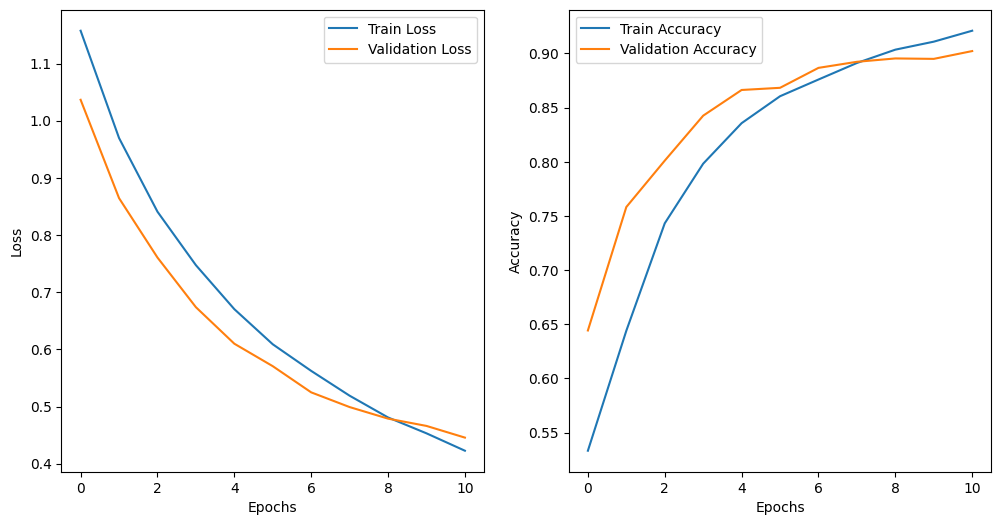

In [23]:
# 학습 결과 시각화
plt.figure(figsize=(12, 6))

# 손실 그래프
plt.subplot(1, 2, 1)
plt.plot(history_dict['loss'], label='Train Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# 정확도 그래프
plt.subplot(1, 2, 2)
plt.plot(history_dict['accuracy'], label='Train Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()
